# 🎯 Smart Portfolio Optimizer

## Modern Portfolio Theory (MPT) - Learning Notebook

This notebook walks you through building a portfolio optimizer step-by-step, explaining each concept along the way.

### What You'll Learn:
1. **Data Fetching** - Getting real stock prices with yfinance
2. **Returns Calculation** - Simple vs Log returns, annualization
3. **Portfolio Statistics** - Covariance matrix, correlation, portfolio math
4. **Monte Carlo Simulation** - Generating thousands of random portfolios
5. **Optimization** - Finding Max Sharpe and Min Volatility portfolios
6. **Visualization** - The famous Efficient Frontier chart

---

# 1. Setting Up the Environment

### Required Libraries:
- **yfinance**: Free API to fetch stock data from Yahoo Finance
- **pandas**: Data manipulation (think Excel in Python)
- **numpy**: Mathematical operations, matrix calculations
- **matplotlib**: Creating charts and visualizations

In [ ]:
# Import all required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# 2. Configuration Variables

Customize your analysis by modifying these variables:

In [ ]:
# Stocks to analyze 
TICKERS = ['AAPL', 'GOOGL', 'MSFT', 'AMZN','BND','XOM','AGG','JNJ','V','PG']  # Tech + Bonds + Diversification

# Date range for historical data
START_DATE = '2024-01-01'
END_DATE = '2026-01-01'

# Simulation parameters
N_PORTFOLIOS = 10000  # More = smoother frontier but slower
RISK_FREE_RATE = 0.05  # Current ~5% US Treasury rate
TRADING_DAYS = 252     # Trading days per year

print(f"📊 Configuration:")
print(f"   Tickers: {TICKERS}")
print(f"   Period: {START_DATE} to {END_DATE}")
print(f"   Portfolios to simulate: {N_PORTFOLIOS:,}")

📊 Configuration:
   Tickers: ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'BND', 'XOM', 'AGG', 'JNJ', 'V', 'PG']
   Period: 2024-01-01 to 2026-01-01
   Portfolios to simulate: 10,000


---

# 3. Data Fetching

### Concept: Getting Historical Stock Prices

Before we can optimize a portfolio, we need **historical price data**.

**Key Terms:**
- **Ticker**: Stock symbol (e.g., 'AAPL' = Apple)
- **Close Price**: The final trading price each day (adjusted for dividends/splits)
- **DataFrame**: A 2D table - rows are dates, columns are stocks

In [ ]:
def fetch_stock_data(tickers, start_date, end_date):
    # Download data using yfinance
    data = yf.download(tickers, start=start_date, end=end_date)
    
    # Get closing prices (already adjusted in newer yfinance)
    prices = data['Close']
    
    # Remove any rows with missing values
    prices = prices.dropna()
    
    return prices

In [ ]:
# Fetch the stock data
prices = fetch_stock_data(TICKERS, START_DATE, END_DATE)

# Get actual column order (yfinance sorts alphabetically)
actual_tickers = list(prices.columns)

print(f"✅ Loaded {len(prices)} trading days of data")
print(f"📋 Columns: {actual_tickers}")
print(f"\n First 5 days:")
prices.head()

[*********************100%***********************]  10 of 10 completed

✅ Loaded 502 trading days of data
📋 Columns: ['AAPL', 'AGG', 'AMZN', 'BND', 'GOOGL', 'JNJ', 'MSFT', 'PG', 'V', 'XOM']

 First 5 days:


Ticker,AAPL,AGG,AMZN,BND,GOOGL,JNJ,MSFT,PG,V,XOM
Date,,,,,,,,,,
2024-01-02,183.731308,91.241928,149.929993,67.715897,137.133850,149.659775,364.589447,140.394638,254.569534,94.847122
2024-01-03,182.355591,91.288124,148.470001,67.771385,137.878235,150.595322,364.324066,139.545120,253.694336,95.643997
2024-01-04,180.039658,90.918648,144.570007,67.466255,135.367172,150.277252,361.709045,140.309662,255.297226,94.810059
2024-01-05,179.317169,90.706215,145.240005,67.262878,134.712158,150.744995,361.522278,139.148682,255.375931,95.097313
2024-01-08,183.652130,91.047981,149.100006,67.558701,137.798843,151.119232,368.344757,140.347443,258.178589,93.512802


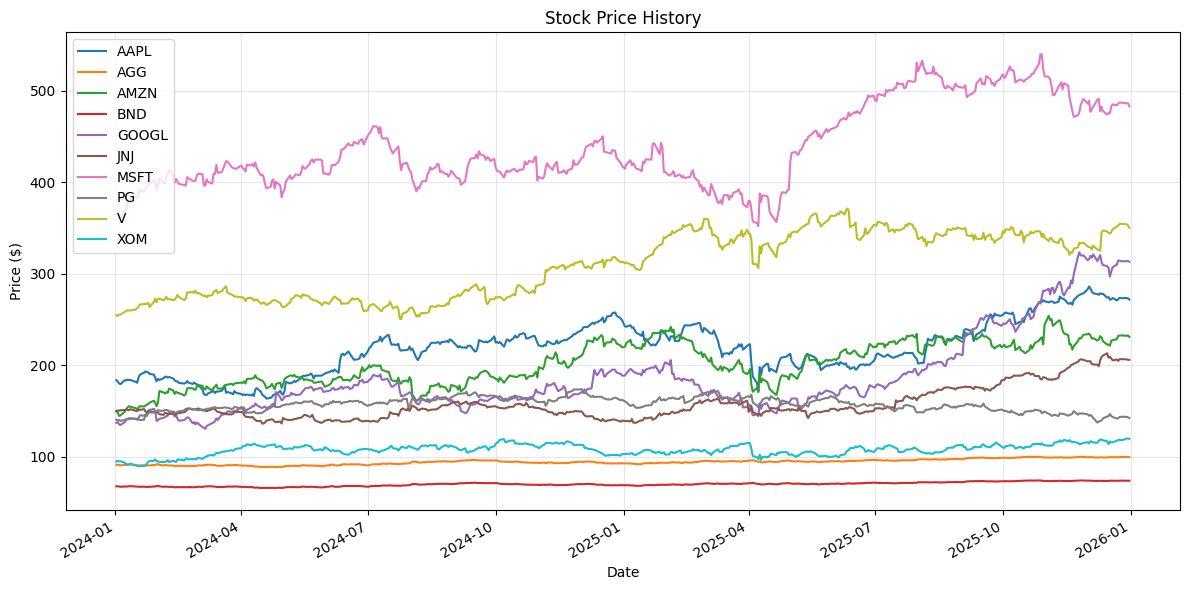

In [ ]:
# Quick visualization of price history
prices.plot(figsize=(12, 6), title='Stock Price History')
plt.ylabel('Price ($)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# 4. Calculating Returns

### Why Returns Instead of Prices?

- A $10 stock going to $11 is the same 10% gain as $100 → $110
- Returns are **comparable** across different price levels
- We can calculate statistics (mean, std) on returns

### Two Types of Returns:

| Type | Formula | Use Case |
|------|---------|----------|
| **Simple** | $(P_t - P_{t-1}) / P_{t-1}$ | Intuitive ("stock up 5%") |
| **Log** | $\ln(P_t / P_{t-1})$ | Can be summed across time, better for stats |

For small daily moves, they're nearly identical!

In [ ]:
def calculate_log_returns(prices):
    """
    Calculate logarithmic returns: r_t = ln(P_t / P_{t-1})
    
    Why log returns?
    - Can be summed across time periods
    - Symmetric: -5% and +5% are truly opposite
    - Better for statistical analysis
    """
    log_returns = np.log(prices).diff().dropna()
    return log_returns


def annualize_returns(daily_returns, trading_days=252):
    """
    Convert daily returns to annualized expected returns.
    Formula: μ_annual = mean(daily) × 252
    """
    return daily_returns.mean() * trading_days


def annualize_volatility(daily_returns, trading_days=252):
    """
    Convert daily volatility to annualized.
    Formula: σ_annual = std(daily) × √252
    
    Why √252? Variance adds, so std = √(var × days) = std × √days
    """
    return daily_returns.std() * np.sqrt(trading_days)

In [ ]:
# Calculate daily log returns
daily_returns = calculate_log_returns(prices)

print("📊 Daily Log Returns (first 5 days):")
daily_returns.head()

📊 Daily Log Returns (first 5 days):


Ticker,AAPL,AGG,AMZN,BND,GOOGL,JNJ,MSFT,PG,V,XOM
Date,,,,,,,,,,
2024-01-03,-0.007516,0.000506,-0.009786,0.000819,0.005413,0.006232,-0.000728,-0.006069,-0.003444,0.008367
2024-01-04,-0.012781,-0.004056,-0.026619,-0.004513,-0.018380,-0.002114,-0.007204,0.005464,0.006298,-0.008757
2024-01-05,-0.004021,-0.002339,0.004624,-0.003019,-0.004851,0.003108,-0.000516,-0.008309,0.000308,0.003025
2024-01-08,0.023887,0.003761,0.026230,0.004388,0.022655,0.002480,0.018696,0.008578,0.010915,-0.016802
2024-01-09,-0.002266,-0.000203,0.015110,-0.000137,0.015083,0.000619,0.002931,0.004094,0.003004,-0.012463


In [ ]:
# Annualize the metrics
annual_returns = annualize_returns(daily_returns)
annual_volatility = annualize_volatility(daily_returns)

# Calculate Sharpe ratios for individual stocks
sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annual_volatility

print("📈 INDIVIDUAL STOCK METRICS")
print("=" * 50)
print(f"{'Ticker':<8} {'Return':>12} {'Volatility':>12} {'Sharpe':>10}")
print("-" * 50)
for ticker in actual_tickers:
    print(f"{ticker:<8} {annual_returns[ticker]:>11.1%} {annual_volatility[ticker]:>11.1%} {sharpe_ratios[ticker]:>10.2f}")
print("=" * 50)
print(f"\n💡 A Sharpe ratio > 1 is generally considered good!")

📈 INDIVIDUAL STOCK METRICS
Ticker         Return   Volatility     Sharpe
--------------------------------------------------
AAPL           19.7%       27.7%       0.53
AGG             4.4%        5.0%      -0.12
AMZN           21.7%       31.3%       0.53
BND             4.3%        5.0%      -0.13
GOOGL          41.5%       30.2%       1.21
JNJ            16.0%       17.5%       0.63
MSFT           14.1%       22.1%       0.41
PG              0.7%       17.1%      -0.25
V              16.0%       19.9%       0.55
XOM            11.6%       21.4%       0.31

💡 A Sharpe ratio > 1 is generally considered good!


---

# 5. Portfolio Statistics (The Heart of MPT!)

### The Covariance Matrix (Σ)

Measures how stock returns **move together**:
- Diagonal elements = variance of each stock  
- Off-diagonal = covariance between pairs

### Portfolio Return: Simple Weighted Average
$$\mu_p = \sum w_i \times \mu_i = w^T \cdot \mu$$

### Portfolio Volatility: THE MAGIC! 🪄
$$\sigma_p = \sqrt{w^T \cdot \Sigma \cdot w}$$

**NOT just weighted average!** Must account for correlations.
- If stocks perfectly correlated: risk = weighted average
- If uncorrelated: risk < weighted average (**diversification benefit!**)

In [ ]:
# Calculate covariance matrix (annualized)
cov_matrix = daily_returns.cov() * TRADING_DAYS

# Calculate correlation matrix
corr_matrix = daily_returns.corr()

print("📊 COVARIANCE MATRIX (Annualized)")
print("=" * 50)
print(cov_matrix.round(4))
print("\n💡 Diagonal = variance, off-diagonal = covariance")

📊 COVARIANCE MATRIX (Annualized)
Ticker    AAPL     AGG    AMZN     BND   GOOGL     JNJ    MSFT      PG  \
Ticker                                                                   
AAPL    0.0766  0.0018  0.0419  0.0017  0.0369  0.0022  0.0290  0.0068   
AGG     0.0018  0.0025 -0.0008  0.0025  0.0001  0.0020  0.0001  0.0020   
AMZN    0.0419 -0.0008  0.0981 -0.0009  0.0511 -0.0084  0.0433 -0.0028   
BND     0.0017  0.0025 -0.0009  0.0025  0.0000  0.0020  0.0001  0.0021   
GOOGL   0.0369  0.0001  0.0511  0.0000  0.0909 -0.0047  0.0324 -0.0044   
JNJ     0.0022  0.0020 -0.0084  0.0020 -0.0047  0.0306 -0.0052  0.0115   
MSFT    0.0290  0.0001  0.0433  0.0001  0.0324 -0.0052  0.0489 -0.0012   
PG      0.0068  0.0020 -0.0028  0.0021 -0.0044  0.0115 -0.0012  0.0293   
V       0.0211  0.0014  0.0207  0.0014  0.0158  0.0085  0.0147  0.0104   
XOM     0.0142  0.0000  0.0092 -0.0000  0.0043  0.0064  0.0032  0.0045   

Ticker       V     XOM  
Ticker                  
AAPL    0.0211  0.0142  
AGG

In [ ]:
print("📊 CORRELATION MATRIX")
print("=" * 50)
print(corr_matrix.round(2))
print("""
💡 Interpretation:
   1.00 = perfectly correlated (same direction)
   0.00 = uncorrelated (independent)
  -1.00 = inversely correlated (opposite)
  
   High correlation = LESS diversification benefit
""")

📊 CORRELATION MATRIX
Ticker  AAPL   AGG  AMZN   BND  GOOGL   JNJ  MSFT    PG     V   XOM
Ticker                                                             
AAPL    1.00  0.13  0.48  0.12   0.44  0.04  0.47  0.14  0.38  0.24
AGG     0.13  1.00 -0.05  1.00   0.00  0.23  0.01  0.24  0.14  0.00
AMZN    0.48 -0.05  1.00 -0.06   0.54 -0.15  0.63 -0.05  0.33  0.14
BND     0.12  1.00 -0.06  1.00   0.00  0.23  0.00  0.24  0.14 -0.00
GOOGL   0.44  0.00  0.54  0.00   1.00 -0.09  0.49 -0.09  0.26  0.07
JNJ     0.04  0.23 -0.15  0.23  -0.09  1.00 -0.13  0.39  0.25  0.17
MSFT    0.47  0.01  0.63  0.00   0.49 -0.13  1.00 -0.03  0.33  0.07
PG      0.14  0.24 -0.05  0.24  -0.09  0.39 -0.03  1.00  0.31  0.12
V       0.38  0.14  0.33  0.14   0.26  0.25  0.33  0.31  1.00  0.25
XOM     0.24  0.00  0.14 -0.00   0.07  0.17  0.07  0.12  0.25  1.00

💡 Interpretation:
   1.00 = perfectly correlated (same direction)
   0.00 = uncorrelated (independent)
  -1.00 = inversely correlated (opposite)

   High correlat

In [ ]:
# Portfolio calculation functions
def portfolio_return(weights, expected_returns):
    """Portfolio return = weighted average of individual returns"""
    return np.dot(weights, expected_returns)


def portfolio_volatility(weights, cov_matrix):
    """Portfolio volatility = sqrt(w^T × Σ × w)"""
    variance = np.dot(weights, np.dot(cov_matrix, weights))
    return np.sqrt(variance)


def portfolio_sharpe(weights, expected_returns, cov_matrix, rf_rate=0.05):
    """Sharpe ratio = (return - risk_free) / volatility"""
    ret = portfolio_return(weights, expected_returns)
    vol = portfolio_volatility(weights, cov_matrix)
    return (ret - rf_rate) / vol

In [ ]:
# Convert to numpy arrays for calculations
exp_ret_array = annual_returns.values
cov_array = cov_matrix.values

# Example: Equal weight portfolio (10% each)
equal_weights = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1 , 0.1, 0.1])  # Adjust if you have more/less stocks

eq_return = portfolio_return(equal_weights, exp_ret_array)
eq_vol = portfolio_volatility(equal_weights, cov_array)
eq_sharpe = portfolio_sharpe(equal_weights, exp_ret_array, cov_array, RISK_FREE_RATE)

print("📊 EQUAL WEIGHT PORTFOLIO EXAMPLE (10% each)")
print("=" * 50)
print(f"   Expected Return: {eq_return:.1%}")
print(f"   Volatility:      {eq_vol:.1%}")
print(f"   Sharpe Ratio:    {eq_sharpe:.2f}")

# Show diversification benefit
avg_individual_vol = np.sqrt(np.diag(cov_array)).mean()
print(f"\n🎁 DIVERSIFICATION BENEFIT:")
print(f"   Average individual volatility: {avg_individual_vol:.1%}")
print(f"   Portfolio volatility:          {eq_vol:.1%}")
print(f"   Risk reduction:                {(avg_individual_vol - eq_vol):.1%}")

📊 EQUAL WEIGHT PORTFOLIO EXAMPLE (10% each)
   Expected Return: 15.0%
   Volatility:      11.1%
   Sharpe Ratio:    0.90

🎁 DIVERSIFICATION BENEFIT:
   Average individual volatility: 19.7%
   Portfolio volatility:          11.1%
   Risk reduction:                8.6%


---

# 6. Monte Carlo Simulation

### The Big Idea:
Instead of solving complex equations, we:
1. Generate **MANY random portfolios** (10,000+)
2. Calculate return/risk/Sharpe for each
3. Plot them all to see the efficient frontier

### Why This Works:
- Easy to implement (no complex optimization)
- Visual and intuitive
- Shows the entire "cloud" of possibilities

In [ ]:
def generate_random_weights(n_assets):
    """Generate random weights that sum to 1 (fully invested)"""
    weights = np.random.random(n_assets)
    return weights / weights.sum()


def simulate_portfolios(expected_returns, cov_matrix, n_portfolios, rf_rate):
    """
    Run Monte Carlo simulation - generate many random portfolios.
    
    Returns arrays of: weights, returns, volatilities, sharpe ratios
    """
    n_assets = len(expected_returns)
    
    # Initialize storage arrays
    all_weights = np.zeros((n_portfolios, n_assets))
    port_returns = np.zeros(n_portfolios)
    port_volatilities = np.zeros(n_portfolios)
    port_sharpes = np.zeros(n_portfolios)
    
    # Generate random portfolios
    for i in range(n_portfolios):
        weights = generate_random_weights(n_assets)
        all_weights[i] = weights
        port_returns[i] = portfolio_return(weights, expected_returns)
        port_volatilities[i] = portfolio_volatility(weights, cov_matrix)
        port_sharpes[i] = portfolio_sharpe(weights, expected_returns, cov_matrix, rf_rate)
    
    return all_weights, port_returns, port_volatilities, port_sharpes

In [ ]:
%%time
# Run the Monte Carlo simulation
print(f"🎲 Simulating {N_PORTFOLIOS:,} random portfolios...")

all_weights, port_returns, port_volatilities, port_sharpes = simulate_portfolios(
    exp_ret_array, cov_array, N_PORTFOLIOS, RISK_FREE_RATE
)

print(f"\n✅ Simulation complete!")
print(f"   Returns range:    {port_returns.min():.1%} to {port_returns.max():.1%}")
print(f"   Volatility range: {port_volatilities.min():.1%} to {port_volatilities.max():.1%}")
print(f"   Sharpe range:     {port_sharpes.min():.2f} to {port_sharpes.max():.2f}")

🎲 Simulating 10,000 random portfolios...

✅ Simulation complete!
   Returns range:    7.6% to 23.6%
   Volatility range: 6.8% to 18.7%
   Sharpe range:     0.36 to 1.27
CPU times: total: 62.5 ms
Wall time: 61.6 ms


---

# 7. Finding Optimal Portfolios

Two key portfolios on the efficient frontier:

| Portfolio | Goal | Best For |
|-----------|------|----------|
| ⭐ **Max Sharpe** | Best risk-adjusted return | Most investors |
| 🛡️ **Min Volatility** | Lowest possible risk | Conservative investors |

In [ ]:
# Find optimal portfolios
max_sharpe_idx = np.argmax(port_sharpes)
min_vol_idx = np.argmin(port_volatilities)

# Extract optimal portfolio details
max_sharpe_weights = all_weights[max_sharpe_idx]
min_vol_weights = all_weights[min_vol_idx]

print("=" * 60)
print("⭐ MAXIMUM SHARPE RATIO PORTFOLIO")
print("=" * 60)
print(f"   Sharpe Ratio:    {port_sharpes[max_sharpe_idx]:.3f}")
print(f"   Expected Return: {port_returns[max_sharpe_idx]:.2%}")
print(f"   Volatility:      {port_volatilities[max_sharpe_idx]:.2%}")
print("\n   Allocation:")
for ticker, weight in zip(actual_tickers, max_sharpe_weights):
    if weight > 0.001:
        bar = "█" * int(weight * 40)
        print(f"     {ticker:5} {weight:6.1%} {bar}")

⭐ MAXIMUM SHARPE RATIO PORTFOLIO
   Sharpe Ratio:    1.275
   Expected Return: 20.36%
   Volatility:      12.05%

   Allocation:
     AAPL    5.2% ██
     AGG     9.5% ███
     AMZN    4.5% █
     BND     2.8% █
     GOOGL  24.2% █████████
     JNJ    26.7% ██████████
     MSFT    4.4% █
     PG      1.5% 
     V       8.8% ███
     XOM    12.3% ████


In [ ]:
print("=" * 60)
print("🛡️  MINIMUM VOLATILITY PORTFOLIO")
print("=" * 60)
print(f"   Sharpe Ratio:    {port_sharpes[min_vol_idx]:.3f}")
print(f"   Expected Return: {port_returns[min_vol_idx]:.2%}")
print(f"   Volatility:      {port_volatilities[min_vol_idx]:.2%}")
print("\n   Allocation:")
for ticker, weight in zip(actual_tickers, min_vol_weights):
    if weight > 0.001:
        bar = "█" * int(weight * 40)
        print(f"     {ticker:5} {weight:6.1%} {bar}")

🛡️  MINIMUM VOLATILITY PORTFOLIO
   Sharpe Ratio:    0.527
   Expected Return: 8.58%
   Volatility:      6.79%

   Allocation:
     AAPL    0.2% 
     AGG    22.6% █████████
     AMZN    1.6% 
     BND    23.0% █████████
     GOOGL   0.7% 
     JNJ    18.9% ███████
     MSFT   13.1% █████
     PG     12.4% ████
     V       1.8% 
     XOM     5.8% ██


---

# 8. Visualization: The Efficient Frontier

The famous chart that shows all possible portfolios:
- **X-axis**: Volatility (Risk)
- **Y-axis**: Expected Return
- **Color**: Sharpe Ratio (brighter = better)

The upper-left boundary is the **Efficient Frontier** - optimal portfolios!

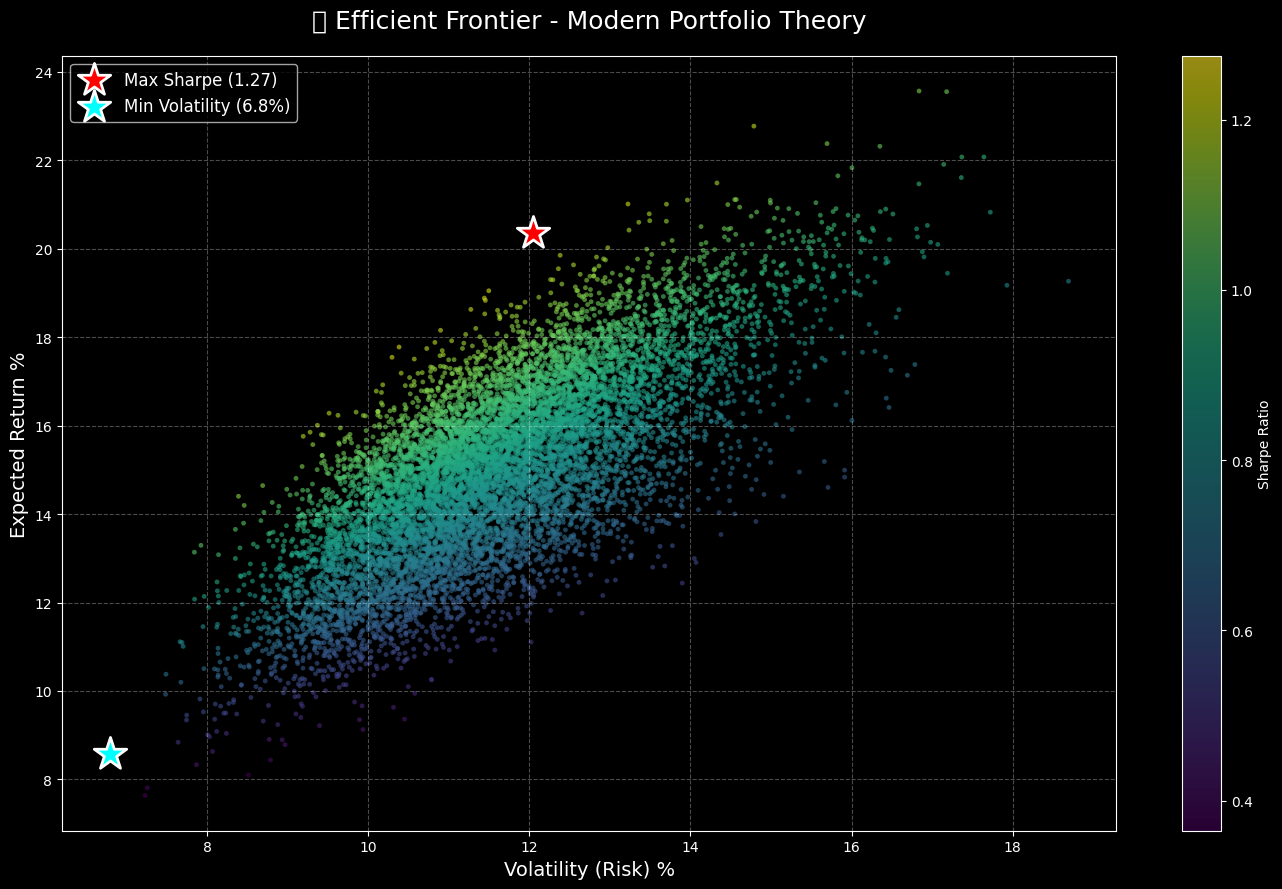


💾 Chart saved as 'efficient_frontier.png'


In [ ]:
# Create the Efficient Frontier visualization
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 9))

# Scatter plot of all portfolios (color by Sharpe)
scatter = ax.scatter(
    port_volatilities * 100,
    port_returns * 100,
    c=port_sharpes,
    cmap='viridis',
    marker='o',
    s=12,
    alpha=0.6,
    edgecolors='none'
)

# Mark Max Sharpe portfolio
ax.scatter(
    port_volatilities[max_sharpe_idx] * 100,
    port_returns[max_sharpe_idx] * 100,
    marker='*',
    color='red',
    s=600,
    edgecolors='white',
    linewidths=2,
    label=f'Max Sharpe ({port_sharpes[max_sharpe_idx]:.2f})',
    zorder=5
)

# Mark Min Volatility portfolio
ax.scatter(
    port_volatilities[min_vol_idx] * 100,
    port_returns[min_vol_idx] * 100,
    marker='*',
    color='cyan',
    s=600,
    edgecolors='white',
    linewidths=2,
    label=f'Min Volatility ({port_volatilities[min_vol_idx]*100:.1f}%)',
    zorder=5
)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

# Labels
ax.set_xlabel('Volatility (Risk) %', fontsize=14, color='white')
ax.set_ylabel('Expected Return %', fontsize=14, color='white')
ax.set_title('📈 Efficient Frontier - Modern Portfolio Theory', fontsize=18, color='white', pad=20)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

print("\n💾 Chart saved as 'efficient_frontier.png'")

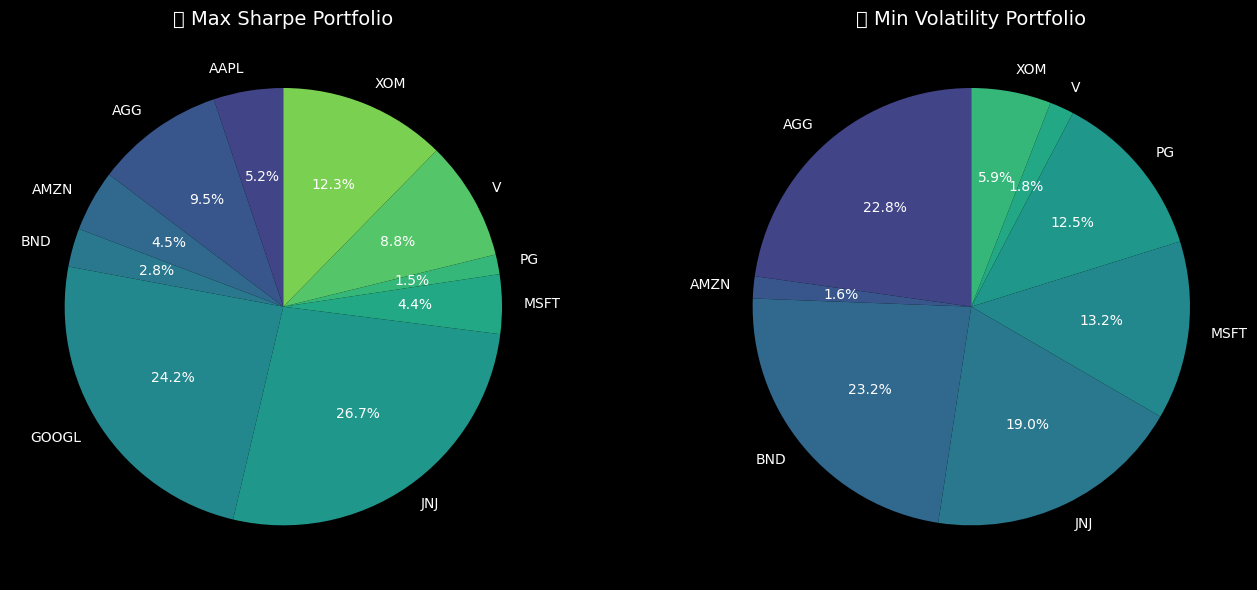

In [ ]:
# Pie charts for portfolio allocations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(actual_tickers)))

# Max Sharpe allocation
ax1 = axes[0]
filtered_ms = [(t, w) for t, w in zip(actual_tickers, max_sharpe_weights) if w > 0.01]
ax1.pie([w for _, w in filtered_ms], labels=[t for t, _ in filtered_ms], 
        autopct='%1.1f%%', colors=colors[:len(filtered_ms)], startangle=90)
ax1.set_title('⭐ Max Sharpe Portfolio', fontsize=14)

# Min Volatility allocation
ax2 = axes[1]
filtered_mv = [(t, w) for t, w in zip(actual_tickers, min_vol_weights) if w > 0.01]
ax2.pie([w for _, w in filtered_mv], labels=[t for t, _ in filtered_mv],
        autopct='%1.1f%%', colors=colors[:len(filtered_mv)], startangle=90)
ax2.set_title('🛡️ Min Volatility Portfolio', fontsize=14)

plt.tight_layout()
plt.show()

---

# 9. Key Takeaways 🎓

### What You Learned:

1. **Data Fetching** - yfinance pulls real market data
2. **Log Returns** - $r = \ln(P_t/P_{t-1})$ - better for statistics  
3. **Covariance Matrix** - measures how stocks move together
4. **Portfolio Volatility** - NOT just weighted average (that's the magic!)
5. **Sharpe Ratio** - risk-adjusted performance metric
6. **Monte Carlo** - simulate thousands of scenarios to explore possibilities
7. **Efficient Frontier** - the optimal risk-return tradeoff

### The "Free Lunch" of Finance:
**Diversification reduces risk without reducing expected return!**

### Next Steps to Learn More:
- Add more stocks from different sectors
- Add constraints (e.g., max 30% in any stock)
- Use `scipy.optimize` for exact optimization
- Explore risk parity strategies

---

# 🎯 Challenge Exercise

Modify the `TICKERS` list at the top to include:
- A bond ETF like `BND` or `AGG`
- A different sector like energy (`XOM`) or healthcare (`JNJ`)

Then re-run all cells and see how the efficient frontier changes!

**Question to think about:** Why might adding bonds improve your portfolio's Sharpe ratio?

---

# 🚀 ADVANCED: Rolling Window Backtest

## Why This Matters

Everything above is **in-sample optimization** — you optimize on data, then evaluate on the SAME data. That's cheating!

**The problem:** Your 93% GOOGL allocation worked from 2024-2025. But would you have known to pick GOOGL in January 2024? No. You're using future information.

**The solution:** Rolling window backtest
1. Train on past data (e.g., 12 months)
2. Optimize portfolio
3. Test on NEXT period (e.g., 1 month)  
4. Roll forward and repeat (Shift → train → test)

This simulates what you'd actually experience as an investor.

In [ ]:
# Fetch MORE data for proper backtesting (need history before 2024)
print("📥 Fetching extended data for backtesting...")
backtest_prices = fetch_stock_data(TICKERS, '2022-01-01', '2026-01-01')
backtest_returns = calculate_log_returns(backtest_prices)

print(f"✅ Loaded {len(backtest_prices)} trading days")
print(f"   Date range: {backtest_prices.index[0].strftime('%Y-%m-%d')} to {backtest_prices.index[-1].strftime('%Y-%m-%d')}")

📥 Fetching extended data for backtesting...


[*********************100%***********************]  10 of 10 completed

✅ Loaded 1003 trading days
   Date range: 2022-01-03 to 2025-12-31


In [ ]:
def find_max_sharpe_portfolio(returns, rf_rate=0.05, n_simulations=5000):
    """Find max Sharpe portfolio using Monte Carlo on given returns data."""
    n_assets = returns.shape[1]
    
    # Calculate statistics from this window
    exp_ret = (returns.mean() * 252).values
    cov = (returns.cov() * 252).values
    
    best_sharpe = -np.inf
    best_weights = None
    
    for _ in range(n_simulations):
        weights = np.random.random(n_assets)
        weights /= weights.sum()
        
        port_ret = np.dot(weights, exp_ret)
        port_vol = np.sqrt(np.dot(weights, np.dot(cov, weights)))
        sharpe = (port_ret - rf_rate) / port_vol
        
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_weights = weights
    
    return best_weights, best_sharpe


def find_min_vol_portfolio(returns, n_simulations=5000):
    """Find minimum volatility portfolio."""
    n_assets = returns.shape[1]
    cov = (returns.cov() * 252).values
    
    best_vol = np.inf
    best_weights = None
    
    for _ in range(n_simulations):
        weights = np.random.random(n_assets)
        weights /= weights.sum()
        
        port_vol = np.sqrt(np.dot(weights, np.dot(cov, weights)))
        
        if port_vol < best_vol:
            best_vol = port_vol
            best_weights = weights
    
    return best_weights, best_vol

In [ ]:
def rolling_backtest(returns, lookback_days=252, rebalance_days=21):
    """
    Rolling window backtest.
    
    Parameters:
    -----------
    returns : DataFrame of daily returns
    lookback_days : Days of history to use for optimization (default 1 year)
    rebalance_days : Days to hold before rebalancing (default ~1 month)
    
    Returns:
    --------
    DataFrame with daily portfolio returns for each strategy
    """
    
    results = {
        'max_sharpe': [],
        'min_vol': [],
        'equal_weight': [],
        'dates': []
    }
    
    n_assets = returns.shape[1]
    equal_weights = np.ones(n_assets) / n_assets
    
    # Current weights (start with equal)
    ms_weights = equal_weights.copy()
    mv_weights = equal_weights.copy()
    
    days_since_rebalance = rebalance_days  # Force rebalance on first valid day
    
    for i in range(lookback_days, len(returns)):
        # Check if we need to rebalance
        if days_since_rebalance >= rebalance_days:
            # Get training window
            train_returns = returns.iloc[i-lookback_days:i]
            
            # Optimize portfolios on training data
            ms_weights, _ = find_max_sharpe_portfolio(train_returns)
            mv_weights, _ = find_min_vol_portfolio(train_returns)
            
            days_since_rebalance = 0
        
        # Get today's returns
        today_returns = returns.iloc[i].values
        
        # Calculate portfolio returns (out-of-sample!)
        ms_ret = np.dot(ms_weights, today_returns)
        mv_ret = np.dot(mv_weights, today_returns)
        eq_ret = np.dot(equal_weights, today_returns)
        
        results['max_sharpe'].append(ms_ret)
        results['min_vol'].append(mv_ret)
        results['equal_weight'].append(eq_ret)
        results['dates'].append(returns.index[i])
        
        days_since_rebalance += 1
    
    return pd.DataFrame(results).set_index('dates')

In [ ]:
%%time
print("🔄 Running rolling window backtest...")
print("   Lookback: 252 days (1 year)")
print("   Rebalance: Every 21 days (~monthly)")
print("   This simulates REAL investing - using only past data!\n")

# Run the backtest
backtest_results = rolling_backtest(backtest_returns, lookback_days=252, rebalance_days=21)

print(f"✅ Backtest complete!")
print(f"   Test period: {backtest_results.index[0].strftime('%Y-%m-%d')} to {backtest_results.index[-1].strftime('%Y-%m-%d')}")
print(f"   Trading days tested: {len(backtest_results)}")

🔄 Running rolling window backtest...
   Lookback: 252 days (1 year)
   Rebalance: Every 21 days (~monthly)
   This simulates REAL investing - using only past data!

✅ Backtest complete!
   Test period: 2023-01-05 to 2025-12-31
   Trading days tested: 750
CPU times: total: 1.42 s
Wall time: 1.44 s


In [ ]:
# Calculate cumulative returns (wealth growth)
cumulative = (1 + backtest_results).cumprod()

# Calculate performance metrics
def calc_metrics(returns, rf_rate=0.05):
    """Calculate key performance metrics."""
    annual_ret = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = (annual_ret - rf_rate) / annual_vol
    
    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'Annual Return': annual_ret,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

# Calculate metrics for each strategy
metrics = {}
for strategy in ['max_sharpe', 'min_vol', 'equal_weight']:
    metrics[strategy] = calc_metrics(backtest_results[strategy])

# Display comparison
print("=" * 70)
print("📊 OUT-OF-SAMPLE PERFORMANCE (This is the REAL test!)")
print("=" * 70)
print(f"\n{'Strategy':<15} {'Return':>12} {'Volatility':>12} {'Sharpe':>10} {'Max DD':>12}")
print("-" * 70)
for strategy, m in metrics.items():
    print(f"{strategy:<15} {m['Annual Return']:>11.1%} {m['Annual Volatility']:>11.1%} {m['Sharpe Ratio']:>10.2f} {m['Max Drawdown']:>11.1%}")
print("=" * 70)

📊 OUT-OF-SAMPLE PERFORMANCE (This is the REAL test!)

Strategy              Return   Volatility     Sharpe       Max DD
----------------------------------------------------------------------
max_sharpe            10.7%       13.4%       0.42      -20.8%
min_vol                8.5%        7.3%       0.49       -7.4%
equal_weight          17.0%       11.1%       1.08      -13.3%


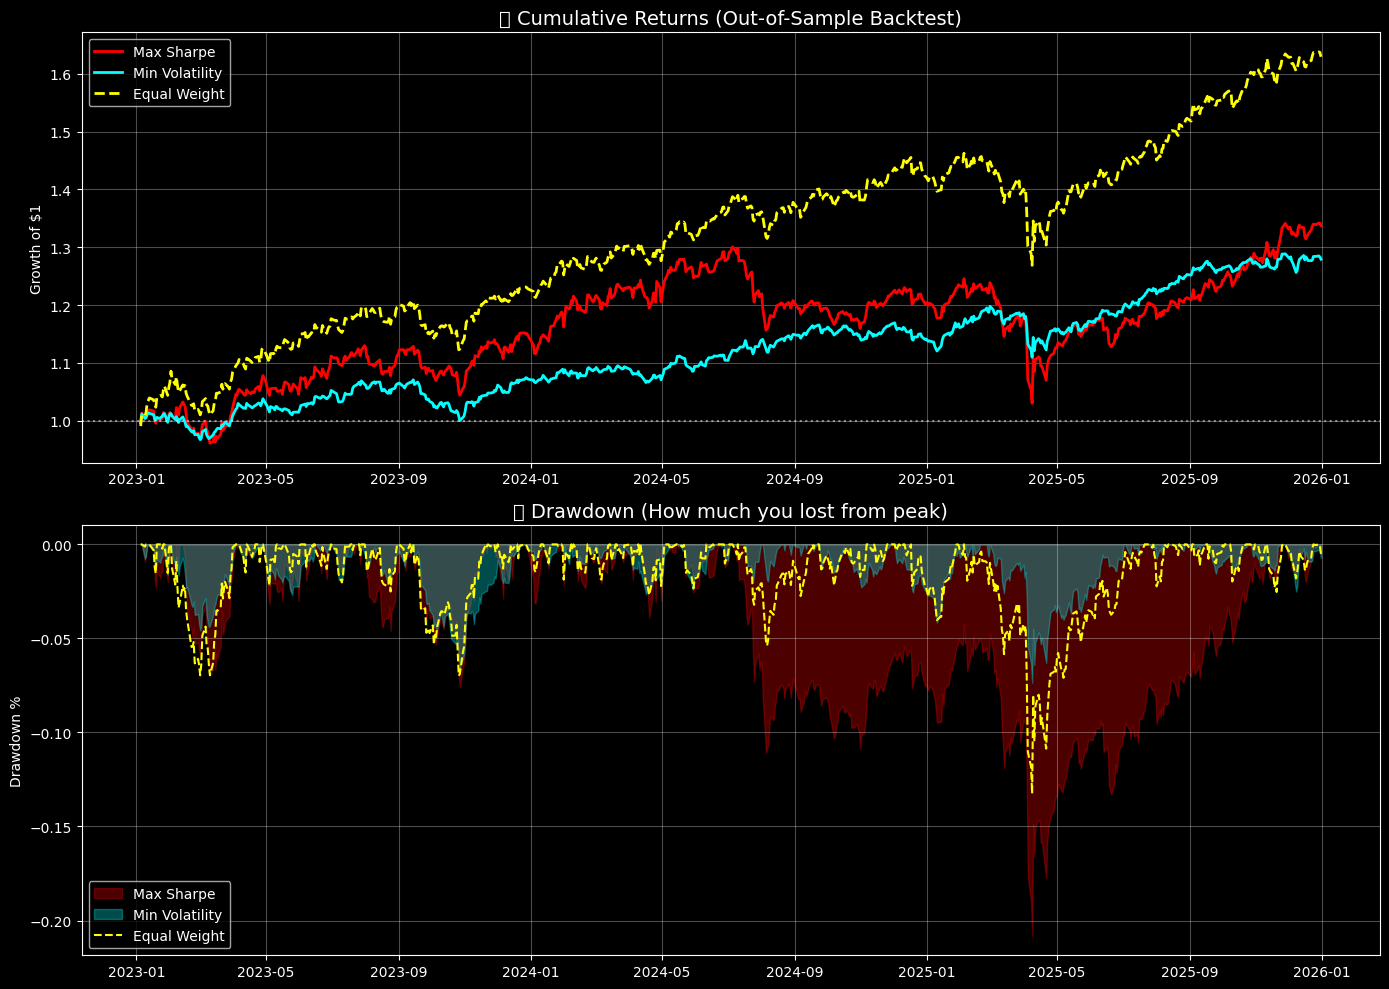

In [ ]:
# Visualize cumulative returns
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative returns (wealth growth)
ax1 = axes[0]
ax1.plot(cumulative.index, cumulative['max_sharpe'], label='Max Sharpe', linewidth=2, color='red')
ax1.plot(cumulative.index, cumulative['min_vol'], label='Min Volatility', linewidth=2, color='cyan')
ax1.plot(cumulative.index, cumulative['equal_weight'], label='Equal Weight', linewidth=2, color='yellow', linestyle='--')
ax1.set_title('📈 Cumulative Returns (Out-of-Sample Backtest)', fontsize=14)
ax1.set_ylabel('Growth of $1')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='white', linestyle=':', alpha=0.5)

# Plot 2: Drawdown
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max

ax2 = axes[1]
ax2.fill_between(drawdown.index, drawdown['max_sharpe'], 0, alpha=0.3, color='red', label='Max Sharpe')
ax2.fill_between(drawdown.index, drawdown['min_vol'], 0, alpha=0.3, color='cyan', label='Min Volatility')
ax2.plot(drawdown.index, drawdown['equal_weight'], color='yellow', linestyle='--', label='Equal Weight')
ax2.set_title('📉 Drawdown (How much you lost from peak)', fontsize=14)
ax2.set_ylabel('Drawdown %')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 Key Insights from Backtesting

### What You Should Notice:

1. **Sharpe ratios are LOWER** than in-sample optimization
   - In-sample Sharpe ≈ 1.2 → Out-of-sample likely < 1.0
   - This is **estimation error** — the biggest problem in MPT

2. **Equal Weight often competes well**
   - Simple strategies are robust because they don't overfit
   - This is called the "1/N puzzle" in academic finance

3. **Max Sharpe may NOT beat Min Volatility**
   - Expected returns are hard to estimate
   - Volatility estimates are more stable
   - "Risk is more predictable than return"

4. **Drawdowns matter**
   - High Sharpe doesn't mean low drawdown
   - Real investors feel losses more than gains

### The Brutal Truth:
> **In-sample optimization is an illusion.** Out-of-sample is reality.

This is why hedge funds spend millions on robust optimization, not basic Markowitz.

In [ ]:
# Compare In-Sample vs Out-of-Sample
print("=" * 70)
print("⚠️  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("=" * 70)

# In-sample metrics (from earlier optimization)
in_sample_sharpe = port_sharpes[max_sharpe_idx]
out_sample_sharpe = metrics['max_sharpe']['Sharpe Ratio']

print(f"\nMax Sharpe Portfolio:")
print(f"  In-Sample Sharpe:  {in_sample_sharpe:.2f}  ← Optimized on full data")
print(f"  Out-Sample Sharpe: {out_sample_sharpe:.2f}  ← Tested on unseen data")
print(f"  Degradation:       {((out_sample_sharpe / in_sample_sharpe) - 1) * 100:.0f}%")

print(f"""
💡 This gap is called "OVERFITTING" or "ESTIMATION ERROR"

The in-sample portfolio looked amazing because it was
optimized on the SAME data it was tested on.

Out-of-sample shows what you'd ACTUALLY experience.
""")

⚠️  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON

Max Sharpe Portfolio:
  In-Sample Sharpe:  1.27  ← Optimized on full data
  Out-Sample Sharpe: 0.42  ← Tested on unseen data
  Degradation:       -67%

💡 This gap is called "OVERFITTING" or "ESTIMATION ERROR"

The in-sample portfolio looked amazing because it was
optimized on the SAME data it was tested on.

Out-of-sample shows what you'd ACTUALLY experience.



---

# 🗺️ Your Learning Roadmap

You've now completed **Step 1** (Rolling Window Backtest). Here's what's ahead:

| Step | Topic | Why It Matters |
|------|-------|----------------|
| ✅ | **Markowitz MPT** | Foundation - you built this! |
| ✅ | **Rolling Backtest** | See the reality of estimation error |
| 2 | **CAPM & Beta** | Understand market risk vs alpha |
| 3 | **Factor Models** | Fama-French, why stocks move together |
| 4 | **Risk Metrics** | VaR, CVaR, Drawdown, Sortino |
| 5 | **Convex Optimization** | `scipy.optimize` instead of Monte Carlo |
| 6 | **Black-Litterman** | Fix MPT's instability with Bayesian views |

### Immediate Next Steps:
1. Try different `lookback_days` (126, 252, 504) - see how it affects results
2. Try different `rebalance_days` (5, 21, 63) - more frequent = more trading costs
3. Add transaction costs to the backtest (0.1% per trade)

**Big insight you should have now:**
> "Optimizing a portfolio is easy. Optimizing it *robustly* is the hard part."

You're no longer a Markowitz beginner. You're starting to think like a quant. 🎓